# Analysis of SNP 100 Data
Data originally obtained from [kaggle.com/datasets/camnugent/sandp500](https://www.kaggle.com/datasets/camnugent/sandp500) List of S&P 100 companies obtained from [en.wikipedia.org/w/index.php?title=S%26P_100&oldid=666413597](https://en.wikipedia.org/w/index.php?title=S%26P_100&oldid=666413597)

In [2]:
import torch
from torch import optim as opt
from torch.nn import functional as F
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import sys
from sklearn.covariance import GraphicalLasso, GraphicalLassoCV
from warnings import warn
sys.path.append(os.path.dirname(os.path.abspath('')))
from MSM.models import variational_models as var_models
from MSM.models import density_models as models
from MSM import utils
from MSM import runners

def first_instance(tensor: torch.Tensor, threshold: float, check_threshold=False):
    if not check_threshold:
        return torch.min(torch.nonzero(tensor>threshold)).item()
    else:
        return torch.min(torch.cat(
            (torch.nonzero(tensor>threshold),torch.tensor([tensor.shape]) - 1))
            ).item()


# Load data from RealData/snp_500_allstocks_5yr.csv
full_data = pd.read_csv('RealData/snp_500_allstocks_5yr.csv')
# Get list of SNP 100 companies
""" list of s_anp_p 100 companies """
with open('RealData/snp_100_names.txt', 'r') as file:
    # Read the single line and split it by commas
    snp_100_list = [item.strip() for item in file.readline().strip().split(',')]
# filter data by Name column to only include SNP 100 companies
data = full_data[full_data['Name'].isin(snp_100_list)]

# Tranpose so that each column represnts the value of the close column from a given stock
data_wide = data.pivot(index='date', columns='Name', values='close')
# Sort by date
data_wide = data_wide.sort_index()

print(data_wide.head())
print(data_wide.tail())

first_10_miss = data_wide.iloc[:10].isna().all()
last_10_miss = data_wide.iloc[-10:].isna().all()
# Remove columns whose first 10 values are NaN
data_wide = data_wide.loc[:, ~first_10_miss]
# Remove columns whose last 10 values are NaN
data_wide = data_wide.loc[:, ~last_10_miss]

# Impute reamining missing values with previous value
data_wide = data_wide.ffill(axis=0)
# Remove any columns still containing NaNs

# Convert to tensor excluding data column
data_tensor = torch.tensor(data_wide.values, dtype=torch.float32)
# Take diff of log of rows
data_tensor = torch.log(data_tensor).diff(dim=0)

# Check number of NaNs
print(f'Number of NaNs in data: {torch.isnan(data_tensor).sum()} out of {data_tensor.numel()}',
      f'with {data_tensor.shape[0]} rows and {data_tensor.shape[1]} columns')

# Normalise across columsn for 0 mean and 1 SD
data_tensor_norm = (data_tensor - data_tensor.mean(dim=0, keepdim=True)) / data_tensor.std(dim=0, keepdim=True)
torch.save(data_tensor_norm, 'RealData/snp_100_data_tensor.pt')
n, dim = data_tensor_norm.shape
lower_indices = torch.tril_indices(row=dim, col=dim, offset=-1)

data_tensor = data_tensor_norm

Name           AAPL   ABBV    ABT    ACN    AIG    ALL   AMGN    AMZN    APA  \
date                                                                           
2013-02-08  67.8542  36.25  34.41  73.31  38.79  45.14  86.77  261.95  84.65   
2013-02-11  68.5614  35.85  34.26  73.07  39.45  45.25  84.92  257.21  83.81   
2013-02-12  66.8428  35.42  34.30  73.37  38.63  45.61  84.54  258.70  84.18   
2013-02-13  66.7156  35.27  34.46  73.56  38.87  45.88  84.94  269.47  84.33   
2013-02-14  66.6556  36.57  34.70  73.13  39.21  45.88  84.72  269.24  80.33   

Name          APC  ...     UNP    UPS    USB    UTX        V     VZ    WBA  \
date               ...                                                       
2013-02-08  84.45  ...  66.575  82.38  33.65  90.09  39.4500  44.35  41.40   
2013-02-11  83.47  ...  66.710  82.69  34.09  89.61  39.0825  44.32  41.48   
2013-02-12  83.45  ...  67.335  82.31  34.31  89.98  39.2000  44.44  41.95   
2013-02-13  84.13  ...  67.645  82.50  33.93  89.

# Uncorrupted Case

## Run unregularised model

In [4]:
# Run model
# Define model
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))

theta_optimizer = opt.SGD(q_theta.parameters(), lr=1e-1)

true_runner = runners.ScoreMatchingRunner(q_theta, theta_optimizer)
true_runner.init_dataset(data_tensor, batch_size=100, drop_last=True)
true_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)

true_runner.train(1000, 1000, snapshot_freq=10)

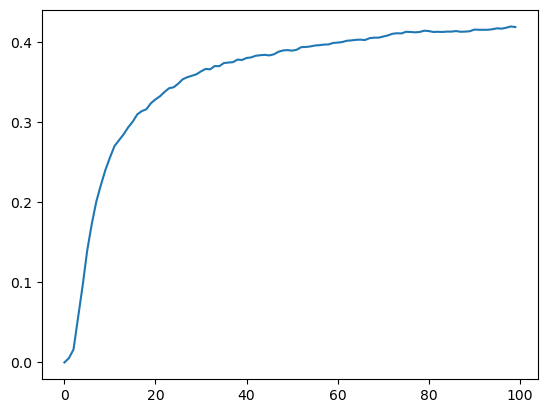

In [5]:
est_precs = torch.stack(utils.convert_state_dicts(true_runner.stored_vals["q_State_dicts"])["Precision"])
positive_rates = torch.mean((est_precs[..., lower_indices[0], lower_indices[1]] > 0).float(), dim=-1)
plt.plot(positive_rates)

In [6]:
torch.diag(torch.inverse(q_theta.Precision))
torch.logdet(q_theta.Precision)

tensor(62.9208, grad_fn=<WhereBackward0>)

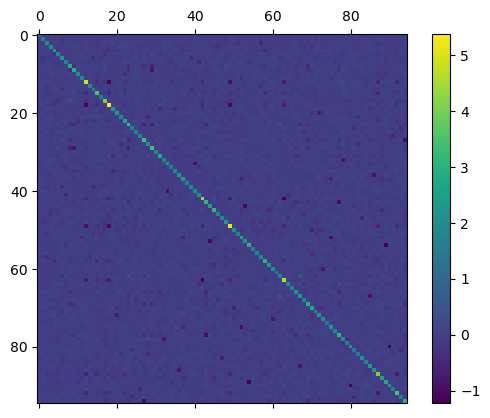

In [7]:
# Plot precision matrix in q_theta.Precision
fig, ax = plt.subplots()
cax = ax.matshow(q_theta.Precision.detach().numpy(), cmap='viridis')
fig.colorbar(cax)

In [8]:
lower_diag = q_theta.Precision[lower_indices[0], lower_indices[1]]
true_quantiles = torch.quantile(lower_diag, torch.tensor([0.9,0.8,0.7,0.6,0.5])).detach().numpy()
true_pos_quantiles = torch.quantile(lower_diag[lower_diag>0], torch.tensor([0.1, 0.01, 0.])).detach().numpy()
true_abs_quantiles = torch.quantile(torch.abs(lower_diag), torch.tensor([0.1, 0.01, 0.])).detach().numpy()

print("Value of quantile for all lower diag points", true_quantiles)
print("Value of quantile for positive lower diag points", true_pos_quantiles)
print("Value of quantiles for absolute data", true_abs_quantiles)

Value of quantile for all lower diag points [ 0.06194018  0.03689538  0.01703688  0.00237612 -0.01107692]
Value of quantile for positive lower diag points [6.3697891e-03 6.4811704e-04 6.4048068e-06]
Value of quantiles for absolute data [7.5498139e-03 7.4722274e-04 6.4048068e-06]


In [2]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
true_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.logspace(-1.7, -4, 101)
niters = torch.tensor([200]+[10]*100).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0},
    {"params": [q_theta.prec_off], "l1_reg":100}
    ], lr=.1)

true_runner = runners.ScoreMatchingRunner(q_theta, theta_optimizer)
true_runner.init_dataset(data_tensor, batch_size=100, drop_last=True)
true_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    try:
        true_runner.train(**training_args)
    except utils.NaNModel:
        print("Nan model")
    except IndexError:
        print("Index Error")

    for key, val in true_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        true_stored_vals[key] += val

change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

torch.Size([1200, 95, 95])
tensor(0.3673)
tensor(0.9015)


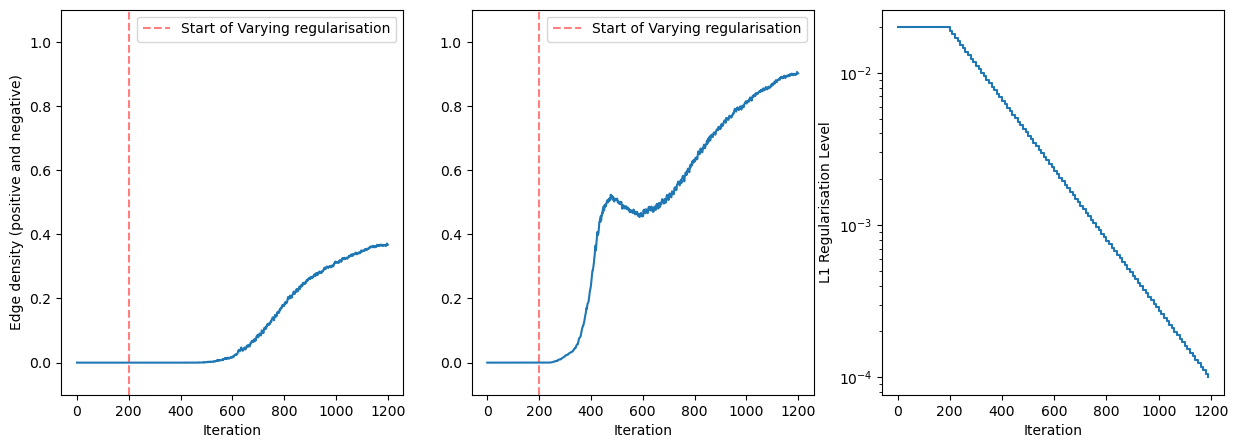

In [3]:
fig,ax = plt.subplots(ncols=3, figsize=(15,5))
q_theta_params = utils.convert_state_dicts(true_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
lower_diag = est_precs[:, lower_indices[0], lower_indices[1]]
print(est_precs.shape)
positive_rates = torch.mean((lower_diag>0.002).float(), dim=-1)
abs_positive_rates = torch.mean((torch.abs(lower_diag)>0.002).float(), dim=-1)
ax[0].plot(positive_rates)
ax[1].plot(abs_positive_rates)
ax[2].step(torch.cat((torch.zeros(1),change_points[:-1])), l1_regs, where="post")
ax[2].set_yscale("log")
true_index = torch.min(torch.nonzero(abs_positive_rates>0.2))
# Plot each change point as a vertical red line
for i in range(2):
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylim(-0.1,1.1)
    ax[i].axvline(change_points[0], linestyle="--", color="red", alpha=0.5, label="Start of Varying regularisation")
    ax[i].legend()
ax[0].set_ylabel("Edge density (positive only)")
ax[0].set_ylabel("Edge density (positive and negative)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("L1 Regularisation Level")
print(positive_rates[-1])
print(abs_positive_rates[-1])

## GraphicalLasso

In [106]:
# Use scikit-learn to find the best l1_reg
mle_thresholds = [0.435,0.305,0.031,0.0185, 0.013]
for threshold in mle_thresholds:
    mle_runner = GraphicalLasso(alpha=threshold, tol=1e-4, max_iter=1000)
    mle_runner.fit(data_tensor.numpy())
    lower_diag = mle_runner.precision_[lower_indices[0], lower_indices[1]]
    nonzero_rate = np.mean(np.abs(lower_diag)>0)
    print(nonzero_rate)

0.10055991041433371
0.20291153415453528
0.30011198208286677
0.400447928331467
0.5036954087346025


In [122]:
# Use scikit-learn to find the best l1_reg
mle_runner = GraphicalLassoCV(tol=1e-3, max_iter=1000)
mle_runner.fit(data_tensor.numpy())
lower_diag = mle_runner.precision_[lower_indices[0], lower_indices[1]]
nonzero_rate = np.mean(np.abs(lower_diag)>0)
print(nonzero_rate)
print(mle_runner.alpha_)

/home/cn21903/anaconda3/envs/DiffusionProcesses/lib/python3.10/site-packages/numpy/core/_methods.py:233: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


0.23045912653975364
0.2521849295885306


/home/cn21903/anaconda3/envs/DiffusionProcesses/lib/python3.10/site-packages/sklearn/covariance/_graph_lasso.py:183: ConvergenceWarning: graphical_lasso: did not converge after 1000 iteration: dual gap: -4.831e-04
  warnings.warn(


In [5]:
true_prec = torch.tensor(mle_runner.precision_)
true_cov = torch.tensor(mle_runner.covariance_)
true_abs = torch.abs(true_prec)>0.002
true_prec_edges = true_prec[true_abs]
true_cov_edges = true_cov[true_abs]
print(torch.mean((true_prec_edges<0).float()).item())
print(torch.mean((true_cov_edges<0).float()).item())

0.9486764073371887
0.0


## Compare Edge Simlarity

In [3]:
# ###### Run MLE ###################################
mle_thresholds = [0.435,0.305,0.031,0.0185, 0.013]
mle_lower_diags = []
for mle_threshold in mle_thresholds:
    mle_runner = GraphicalLasso(alpha=mle_threshold, tol=1e-4, max_iter=1000)
    mle_runner.fit(data_tensor.numpy())
    mle_lower_diags.append(torch.tensor(mle_runner.precision_)[lower_indices[0], lower_indices[1]])
mle_lower_diags = torch.stack(mle_lower_diags, dim=0)
mle_abs_adjs = torch.abs(mle_lower_diags)>0.0

# ###### Run Score Matching ########################
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
sm_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.logspace(-1.7, -4, 101)
niters = torch.tensor([200]+[10]*100).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0},
    {"params": [q_theta.prec_off], "l1_reg":0.02}
    ], lr=.1)

sm_runner = runners.ScoreMatchingRunner(q_theta, theta_optimizer)
sm_runner.init_dataset(data_tensor, batch_size=100, drop_last=True)
sm_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    sm_runner.train(**training_args)
    for key, val in sm_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        sm_stored_vals[key] += val

change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

q_theta_params = utils.convert_state_dicts(sm_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
sm_lower_diags = est_precs[..., lower_indices[0], lower_indices[1]]
sm_abs_adjs_full = torch.abs(sm_lower_diags)>0.002
abs_positive_rates = torch.mean(sm_abs_adjs_full.float(), dim=-1)
abs_threshold = torch.linspace(0.1, 0.5, 5)

sm_abs_indices = [utils.data.gen_inverse_ind(abs_positive_rates, threshold, True) for threshold in abs_threshold]
sm_abs_adjs = sm_abs_adjs_full[sm_abs_indices]

# Print positive rates of sm_abs_adjs_subset and mle_abs_adjs
print(f"Positive rates of score matching models are: {torch.mean(sm_abs_adjs.float(), dim=-1)}")
print(f"Positive rates of MLE models are: {torch.mean(mle_abs_adjs.float(), dim=-1)}")

print(f"Agreement betweeen models are: {torch.mean((sm_abs_adjs == mle_abs_adjs).float(), dim=-1)}")

Positive rates of score matching models are: tensor([0.1008, 0.2052, 0.3037, 0.4043, 0.5006])
Positive rates of MLE models are: tensor([0.1006, 0.2029, 0.3001, 0.4004, 0.5037])
Agreement betweeen models are: tensor([0.9662, 0.9351, 0.7796, 0.6786, 0.6022])


# Corrupted Case

In [8]:
# Create corrupted data
missing_prob = 0.5
mask = torch.bernoulli((1-missing_prob)*torch.ones_like(data_tensor))
missing_data = data_tensor*mask
missing_data_globalnorm = data_tensor_globalnorm*mask

## Variational

Value of quantile for all lower diag points [ 0.04480655  0.02428759  0.01007822 -0.00204596 -0.01331866]
Value of quantile for positive lower diag points [4.4470187e-03 3.8001197e-04 8.2712296e-07]
Value of quantiles for absolute data [1.7968392e-02 5.9964471e-03 6.1228574e-04 8.2712296e-07]


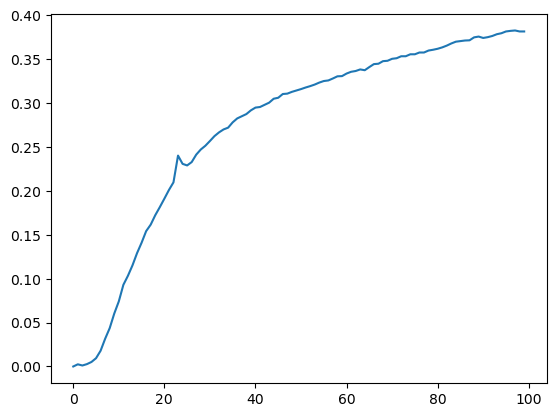

In [25]:
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
p_phi = var_models.VariationalMLPConstVarNormal(dim=dim)
phi_optimizer = opt.Adam(p_phi.parameters(), lr=0.01)

theta_optimizer = opt.SGD(q_theta.parameters(), lr=.001)

temp_runner = runners.BiLevelMarginal(
    q_theta, p_phi, theta_optimizer, phi_optimizer,
    n_phi_step=10, do_iw=False, ncopies=10,inner_loss="fisher")
temp_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
temp_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
temp_runner.train(1000, 1000, snapshot_freq=10)
# Get quantiles of lower diagonal of precision matrix
lower_indices = torch.tril_indices(dim, dim, offset=-1)
lower_diag = q_theta.Precision[lower_indices[0], lower_indices[1]]
variational_quantiles = torch.quantile(lower_diag, torch.tensor([0.9,0.8,0.7,0.6,0.5])).detach().numpy()
variational_pos_quantiles = torch.quantile(lower_diag[lower_diag>0], torch.tensor([0.1, 0.01, 0.])).detach().numpy()
variational_abs_quantiles = torch.quantile(torch.abs(lower_diag), torch.tensor([0.3,0.1, 0.01, 0.])).detach().numpy()

print("Value of quantile for all lower diag points", variational_quantiles)
print("Value of quantile for positive lower diag points", variational_pos_quantiles)
print("Value of quantiles for absolute data", variational_abs_quantiles)

est_precs = torch.stack(utils.convert_state_dicts(temp_runner.stored_vals["q_State_dicts"])["Precision"])
positive_rates = torch.mean((est_precs[..., lower_indices[0], lower_indices[1]] > 0).float(), dim=-1)
plt.plot(positive_rates)

In [10]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
variational_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.logspace(1, -4, 201)
niters = torch.tensor([200]+[10]*200).int()
change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
p_phi = var_models.VariationalMLPConstVarNormal(dim=dim)
phi_optimizer = opt.Adam(p_phi.parameters(), lr=0.001)

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0.},
    {"params": [q_theta.prec_off], "l1_reg":.2}
    ], lr=.0005)

variational_runner = runners.BiLevelMarginal(q_theta, p_phi, theta_optimizer, phi_optimizer,
                                 n_phi_step=10, do_iw=False, ncopies=10,inner_loss="fisher")
variational_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
variational_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    # Run training
    variational_runner.train(**training_args)
    
    # Store results
    variational_runner.stored_vals.pop("p_State_dicts")
    for key, val in variational_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        variational_stored_vals[key] += val


torch.Size([2200, 95, 95])
tensor(0.3919)
tensor(1.)


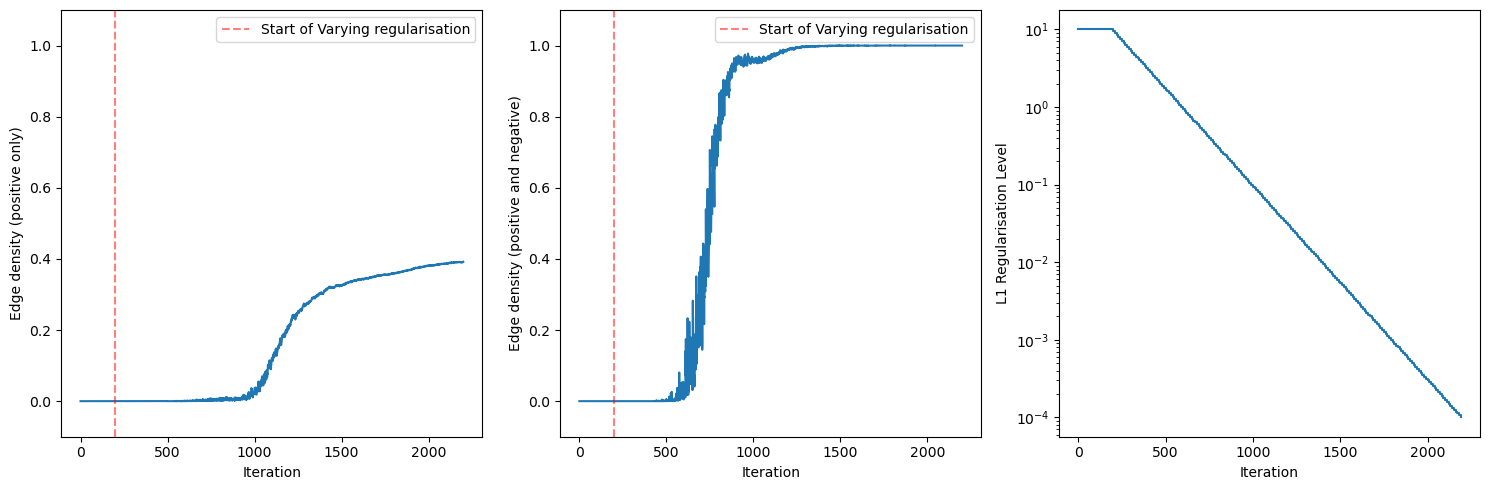

In [38]:
niters = torch.tensor([200]+[10]*200).int()
change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()
fig,ax = plt.subplots(ncols=3, figsize=(15,5))
q_theta_params = utils.convert_state_dicts(variational_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
lower_diag = est_precs[:, lower_indices[0], lower_indices[1]]
print(est_precs.shape)
positive_rates = torch.mean((lower_diag>1e-6).float(),dim=-1)
abs_positive_rates = torch.mean((torch.abs(lower_diag)>1e-6).float(), dim=-1)
ax[0].plot(positive_rates)
ax[1].plot(abs_positive_rates)
ax[2].step(torch.cat((torch.zeros(1),change_points[:-1])), l1_regs, where="post")
ax[2].set_yscale("log")

variational_nonabs_index = torch.min(torch.nonzero(positive_rates>0.25))
variational_abs_index = torch.min(torch.nonzero(abs_positive_rates>0.5))
# Plot each change point as a vertical red line
for i in range(2):
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylim(-0.1,1.1)
    ax[i].axvline(change_points[0], linestyle="--", color="red", alpha=0.5, label="Start of Varying regularisation")
    ax[i].legend()
ax[0].set_ylabel("Edge density (positive only)")
ax[1].set_ylabel("Edge density (positive and negative)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("L1 Regularisation Level")
fig.tight_layout()
print(positive_rates[-1])
print(abs_positive_rates[-1])

In [70]:
out = threshold_selector(torch.abs(lower_diag)[change_points-1], threshold=0.01, iters=3, steps=100, type="changes", angles=False)
print(out)
scores = torch.abs(lower_diag)
# Get positive rates for thresholds in shape (steps, nchange_points)
temp_positive_rates = torch.mean((scores > out).float(), dim=-1)
print(temp_positive_rates.shape)
print(pos_rate_reg(temp_positive_rates))

torch.Size([2200, 4465])
Current range: (1e-06, 0.1)
Reg levels at current range are: (tensor(0.1420), tensor(0.))
Current range: (0.004862601403146982, 0.005462277214974165)
Reg levels at current range are: (tensor(0.0101), tensor(0.0076))
Current range: (0.005181039683520794, 0.0051871296018362045)
Reg levels at current range are: (tensor(0.0110), tensor(0.0047))
0.005182577762752771
torch.Size([2200])
tensor(305.2478)


### Plot Performance

0.0012118148151785135
AUC: 0.901


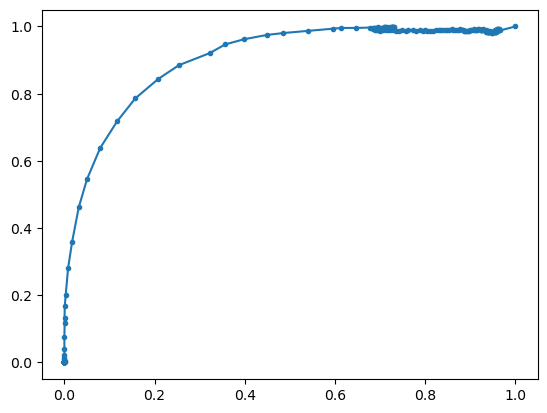

In [69]:
change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()
est_precs = torch.stack([variational_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this
print(out)
est_abs = torch.abs(est_precs)>out
true_abs = (torch.abs(true_prec)>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to beginning and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

AUC: 0.889


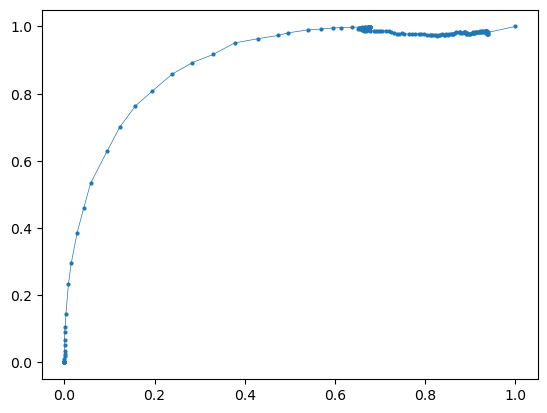

In [13]:
l1_regs = torch.logspace(1, -4, 201)
change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()
est_precs = torch.stack([variational_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.002
true_abs = (torch.abs(torch.tensor(mle_runner.precision_))>0).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to beginning and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=2, linewidth=0.5)
plt.show()

## MissDiff-Param

Value of quantile for all lower diag points [ 0.05029124  0.02693526  0.01087529 -0.00275932 -0.01494832]
Value of quantile for positive lower diag points [5.2056764e-03 4.5642877e-04 7.6255428e-06]
Value of quantiles for absolute data [6.6611590e-03 5.9158757e-04 6.9774114e-06]


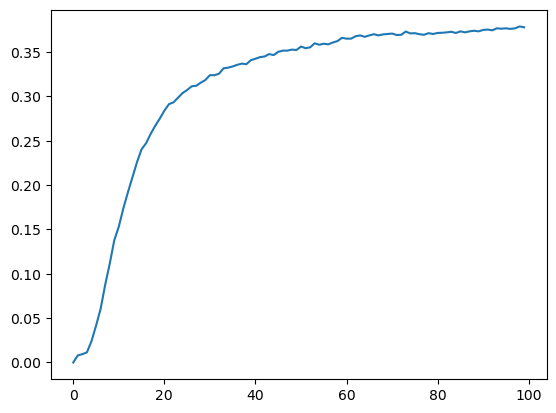

In [32]:
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
zero_imputer = var_models.ConstantImputer(torch.zeros(1))
theta_optimizer = opt.SGD(q_theta.parameters(), lr=.1)

temp_runner = runners.ImputingZerodScoreMatchingRunner(
    q_theta, zero_imputer, theta_optimizer)
temp_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
temp_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
temp_runner.train(1000, 1000, snapshot_freq=10)
# Get quantiles of lower diagonal of precision matrix
lower_indices = torch.tril_indices(dim, dim, offset=-1)
lower_diag = q_theta.Precision[lower_indices[0], lower_indices[1]]
missdiff_quantiles = torch.quantile(lower_diag, torch.tensor([0.9,0.8,0.7,0.6,0.5])).detach().numpy()
missdiff_pos_quantiles = torch.quantile(lower_diag[lower_diag>0], torch.tensor([0.1, 0.01, 0.])).detach().numpy()
missdiff_abs_quantiles = torch.quantile(torch.abs(lower_diag), torch.tensor([0.1, 0.01, 0.])).detach().numpy()
print("Value of quantile for all lower diag points", missdiff_quantiles)
print("Value of quantile for positive lower diag points", missdiff_pos_quantiles)
print("Value of quantiles for absolute data", missdiff_abs_quantiles)

est_precs = torch.stack(utils.convert_state_dicts(temp_runner.stored_vals["q_State_dicts"])["Precision"])
positive_rates = torch.mean((est_precs[..., lower_indices[0], lower_indices[1]] > 0).float(), dim=-1)
plt.plot(positive_rates)

In [14]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
missdiff_stored_vals = {"Losses": [], "q_State_dicts": []}

# l1_regs = torch.cat((torch.logspace(np.log10(levels[0]), np.log10(levels[1]), 101),torch.zeros(1)))
l1_regs = torch.cat((torch.logspace(1, -4, 201),torch.zeros(1)))
niters = torch.tensor([200]+[10]*200+[50]).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
zero_imputer = var_models.ConstantImputer(torch.zeros(1))

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0.},
    {"params": [q_theta.prec_off], "l1_reg":0.02}
    ], lr=.0005)

missdiff_runner = runners.ImputingZerodScoreMatchingRunner(q_theta, zero_imputer, theta_optimizer)
missdiff_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
missdiff_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    try:
        missdiff_runner.train(**training_args)
    except utils.NaNModel:
        print("Nan model")
    except IndexError:
        print("Index Error")
    for key, val in missdiff_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        missdiff_stored_vals[key] += val

change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

torch.Size([2250, 94, 94])
tensor(0.0009)
tensor(0.9835)


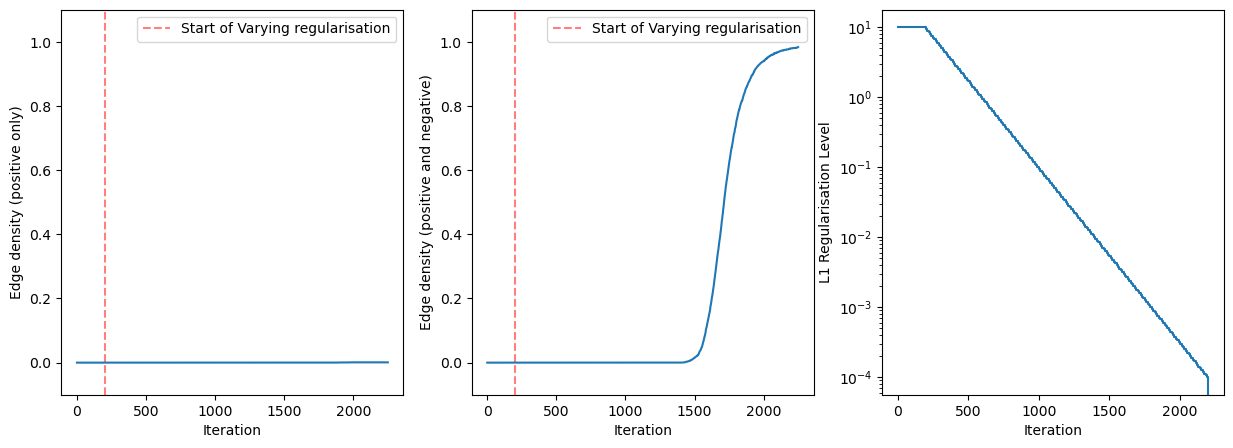

In [21]:
niters = torch.tensor([200]+[10]*200+[50]).int()
change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

fig,ax = plt.subplots(ncols=3, figsize=(15,5))
q_theta_params = utils.convert_state_dicts(missdiff_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
lower_diag = est_precs[:, lower_indices[0], lower_indices[1]]
print(est_precs.shape)
positive_rates = torch.mean((lower_diag>0.0002).float(),dim=-1)
abs_positive_rates = torch.mean((torch.abs(lower_diag)>0.0002).float(), dim=-1)
ax[0].plot(positive_rates)
ax[1].plot(abs_positive_rates)
ax[2].step(torch.cat((torch.zeros(1),change_points[:-1])), l1_regs, where="post")
ax[2].set_yscale("log")
# missdiff_index = torch.min(torch.nonzero(abs_positive_rates>0.5))
# Plot each change point as a vertical red line
for i in range(2):
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylim(-0.1,1.1)
    ax[i].axvline(change_points[0], linestyle="--", color="red", alpha=0.5, label="Start of Varying regularisation")
    ax[i].legend()
ax[0].set_ylabel("Edge density (positive only)")
ax[1].set_ylabel("Edge density (positive and negative)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("L1 Regularisation Level")
print(positive_rates[-1])
print(abs_positive_rates[-1])

### Plot Results

AUC: 0.923


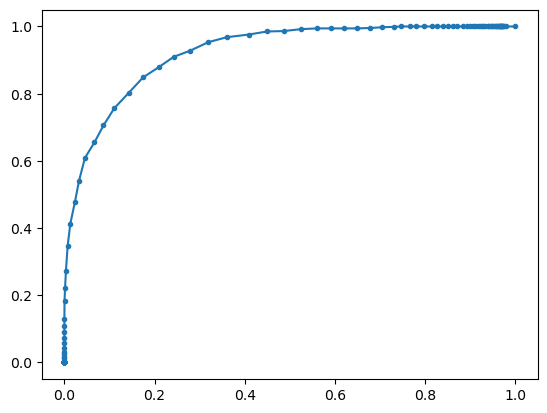

In [23]:
est_precs = torch.stack([missdiff_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.0002
true_abs = (torch.abs(true_prec)>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

AUC: 0.891


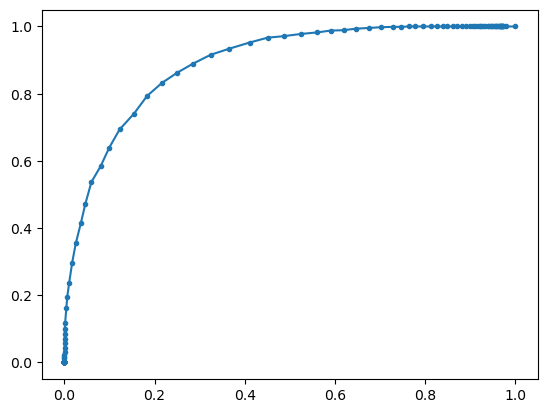

In [18]:
est_precs = torch.stack([missdiff_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.0002
true_abs = (torch.abs(torch.tensor(mle_runner.precision_))>0.000).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

In [143]:
select_ind = torch.nonzero(fpr>0.2)[0,0]
print(select_ind)


print(torch.mean((est_precs[select_ind][est_abs[select_ind]]<0).float()))
print(est_precs[select_ind][~est_abs[select_ind]])

tensor(47)
tensor(0.9423)
tensor([-0.0000, 0.0013, 0.0001,  ..., 0.0017, 0.0002, 0.0002])


## Importance Weighting

Value of quantile for all lower diag points [ 0.06507645  0.03199651  0.00916356 -0.01015587 -0.02828975]
Value of quantile for positive lower diag points [5.7894206e-03 5.0156977e-04 9.8547825e-06]
Value of quantiles for absolute data [9.5883496e-03 8.7703974e-04 9.8547825e-06]


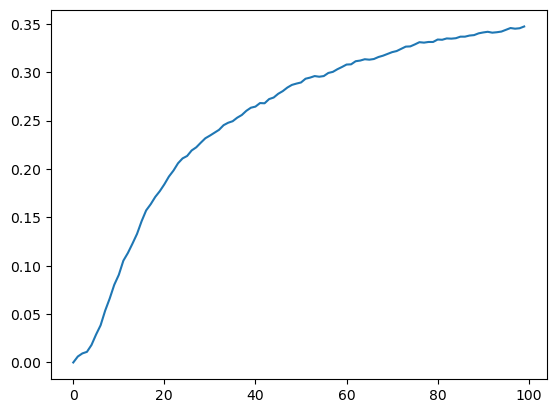

In [42]:
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
fixed_phi = var_models.VariationalConstantNormal(
        dim=dim, mean=torch.zeros(dim), std=0.1 * torch.ones(dim)
    )

theta_optimizer = opt.SGD(q_theta.parameters(), lr=.1)

temp_runner = runners.IWScoreMatchingRunner(
    q_theta, fixed_phi, theta_optimizer, ncopies=10)
temp_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
temp_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
temp_runner.train(1000, 1000, snapshot_freq=10)

# Get quantiles of lower diagonal of precision matrix
lower_indices = torch.tril_indices(dim, dim, offset=-1)
lower_diag = q_theta.Precision[lower_indices[0], lower_indices[1]]
iw_quantiles = torch.quantile(lower_diag, torch.tensor([0.9,0.8,0.7,0.6,0.5])).detach().numpy()
iw_pos_quantiles = torch.quantile(lower_diag[lower_diag>0], torch.tensor([0.1, 0.01, 0.])).detach().numpy()
iw_abs_quantiles = torch.quantile(torch.abs(lower_diag), torch.tensor([0.1, 0.01, 0.])).detach().numpy()
print("Value of quantile for all lower diag points", iw_quantiles)
print("Value of quantile for positive lower diag points", iw_pos_quantiles)
print("Value of quantiles for absolute data", iw_abs_quantiles)

# Plot positive rates over time
est_precs = torch.stack(utils.convert_state_dicts(temp_runner.stored_vals["q_State_dicts"])["Precision"])
positive_rates = torch.mean((est_precs[..., lower_indices[0], lower_indices[1]] > 0).float(), dim=-1)
plt.plot(positive_rates)

In [74]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
iw_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.logspace(1, -4, 201)
niters = torch.tensor([200]+[10]*200).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
fixed_phi = var_models.VariationalConstantNormal(
        dim=dim, mean=torch.zeros(dim), std=0.1 * torch.ones(dim)
    )

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0.},
    {"params": [q_theta.prec_off], "l1_reg":.02}
    ], lr=.001)

iw_runner = runners.IWScoreMatchingRunner(
    q_theta, fixed_phi, theta_optimizer, ncopies=10)
iw_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
iw_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    try:
        iw_runner.train(**training_args)
    except utils.NaNModel:
        print("Nan model")
    except IndexError:
        print("Index Error")
    for key, val in iw_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        iw_stored_vals[key] += val

change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

torch.Size([2200, 95, 95])
tensor(0.)
tensor(0.6739)


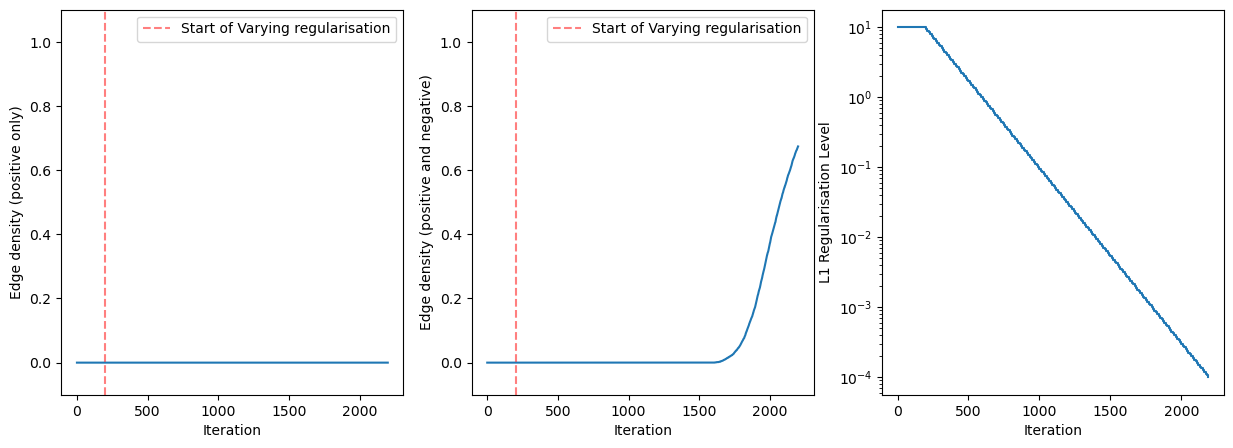

In [76]:
fig,ax = plt.subplots(ncols=3, figsize=(15,5))
q_theta_params = utils.convert_state_dicts(iw_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
lower_diag = est_precs[:, lower_indices[0], lower_indices[1]]
print(est_precs.shape)
positive_rates = torch.mean((lower_diag>0.002).float(),dim=-1)
abs_positive_rates = torch.mean((torch.abs(lower_diag)>0.002).float(), dim=-1)
ax[0].plot(positive_rates)
ax[1].plot(abs_positive_rates)
ax[2].step(torch.cat((torch.zeros(1),change_points[:-1])), l1_regs, where="post")
ax[2].set_yscale("log")
# iw_index = torch.min(torch.nonzero(abs_positive_rates>0.5))
# Plot each change point as a vertical red line
for i in range(2):
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylim(-0.1,1.1)
    ax[i].axvline(change_points[0], linestyle="--", color="red", alpha=0.5, label="Start of Varying regularisation")
    ax[i].legend()
ax[0].set_ylabel("Edge density (positive only)")
ax[1].set_ylabel("Edge density (positive and negative)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("L1 Regularisation Level")
print(positive_rates[-1])
print(abs_positive_rates[-1])

In [78]:
print(lower_diag.shape)
out = threshold_selector(torch.abs(lower_diag)[change_points-1], threshold=0.01, iters=3, steps=100, type="changes", angles=False)
print(out)
scores = torch.abs(lower_diag)
# Get positive rates for thresholds in shape (steps, nchange_points)
temp_positive_rates = torch.mean((scores > out).float(), dim=-1)

torch.Size([2200, 4465])
Current range: (1e-06, 0.1)
Reg levels at current range are: (tensor(0.0307), tensor(0.))
Current range: (8.111308488878421e-06, 9.111627150559798e-06)
Reg levels at current range are: (tensor(0.0103), tensor(0.0067))
Current range: (8.28464180813171e-06, 8.294379767903592e-06)
Reg levels at current range are: (tensor(0.0101), tensor(0.0099))
8.290251571452245e-06


### Plot Results

AUC: 0.910


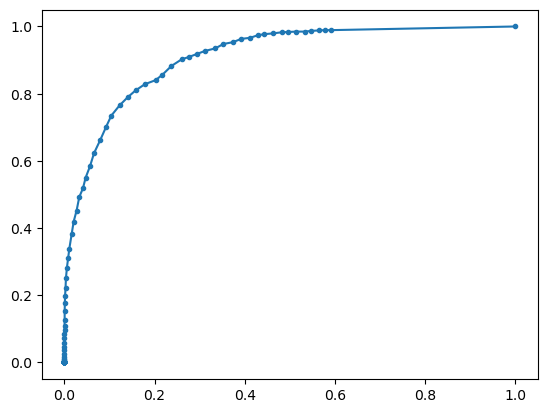

In [79]:
est_precs = torch.stack([iw_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.002
true_abs = (torch.abs(true_prec)>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

AUC: 0.866


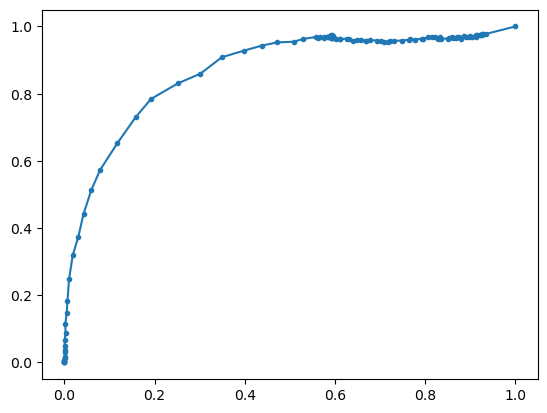

In [94]:
est_precs = torch.stack([iw_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.002
true_abs = (torch.abs(torch.tensor(mle_runner.precision_))>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

## EM

Value of quantile for all lower diag points [ 0.06519424  0.0324886   0.00945634 -0.01025095 -0.0281256 ]
Value of quantile for positive lower diag points [0.00700441 0.00070744 0.00014615]
Value of quantiles for absolute data [9.7479830e-03 8.9089689e-04 1.4789356e-05]


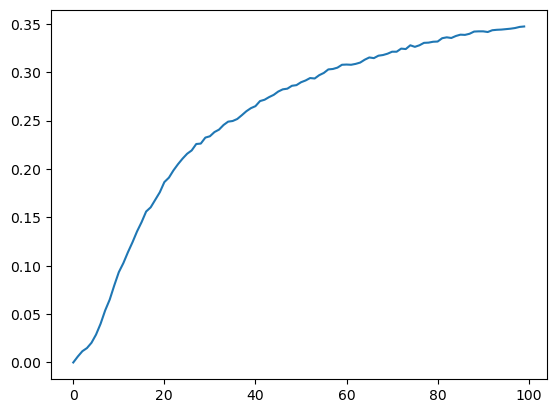

In [64]:
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
fixed_phi = var_models.VariationalConstantNormal(
        dim=dim, mean=torch.zeros(dim), std=0.1 * torch.ones(dim)
    )

theta_optimizer = opt.SGD(q_theta.parameters(), lr=.1)

temp_runner = runners.EMScoreMatchingRunner(
    q_theta, fixed_phi, theta_optimizer, ncopies=10)
temp_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
temp_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
temp_runner.train(1000, 1000, snapshot_freq=10)

# Get quantiles of lower diagonal of precision matrix
lower_indices = torch.tril_indices(dim, dim, offset=-1)
lower_diag = q_theta.Precision[lower_indices[0], lower_indices[1]]
em_quantiles = torch.quantile(lower_diag, torch.tensor([0.9,0.8,0.7,0.6,0.5])).detach().numpy()
em_pos_quantiles = torch.quantile(lower_diag[lower_diag>0], torch.tensor([0.1, 0.01, 0.])).detach().numpy()
em_abs_quantiles = torch.quantile(torch.abs(lower_diag), torch.tensor([0.1, 0.01, 0.])).detach().numpy()
print("Value of quantile for all lower diag points", em_quantiles)
print("Value of quantile for positive lower diag points", em_pos_quantiles)
print("Value of quantiles for absolute data", em_abs_quantiles)

# Plot positive rates over time
est_precs = torch.stack(utils.convert_state_dicts(temp_runner.stored_vals["q_State_dicts"])["Precision"])
positive_rates = torch.mean((est_precs[..., lower_indices[0], lower_indices[1]] > 0).float(), dim=-1)
plt.plot(positive_rates)

In [49]:
training_args = {
    "nepochs": 10000,
    "snapshot_freq": 1,
    "min_loss_val": -1e6}
em_stored_vals = {"Losses": [], "q_State_dicts": []}

l1_regs = torch.logspace(-1.7, -4, 101)
niters = torch.tensor([200]+[10]*100).int()
q_theta = models.NormalSymDensity(dim=dim, mean=torch.zeros(dim), Precision=torch.eye(dim))
fixed_phi = var_models.VariationalConstantNormal(
        dim=dim, mean=torch.zeros(dim), std=0.1 * torch.ones(dim)
    )

theta_optimizer = utils.Prox_SGD([
    {"params":[q_theta.prec_diag], "l1_reg":0.},
    {"params": [q_theta.prec_off], "l1_reg":0.02}
    ], lr=.1)

em_runner = runners.EMScoreMatchingRunner(
    q_theta, fixed_phi, theta_optimizer, ncopies=10)
em_runner.init_dataset(missing_data, mask, batch_size=100, drop_last=True)
em_runner.set_grad_opts(control_method="clip", max_norm=0.5, norm_type=2)
for i, l1_reg in enumerate(l1_regs):
    # Update optimiser
    theta_optimizer.param_groups[1]["l1_reg"] = l1_reg.item()
    # Update training args
    training_args["niters"] = niters[i].item()
    try:
        em_runner.train(**training_args)
    except utils.NaNModel:
        print("Nan model")
    except IndexError:
        print("Index Error")
    for key, val in em_runner.stored_vals.items():
        # Add stored vals from this run to all stored_vals
        em_stored_vals[key] += val

change_points = (torch.cumsum(niters,0)/training_args["snapshot_freq"]).int()

torch.Size([1200, 94, 94])
tensor(0.2464)
tensor(0.7673)


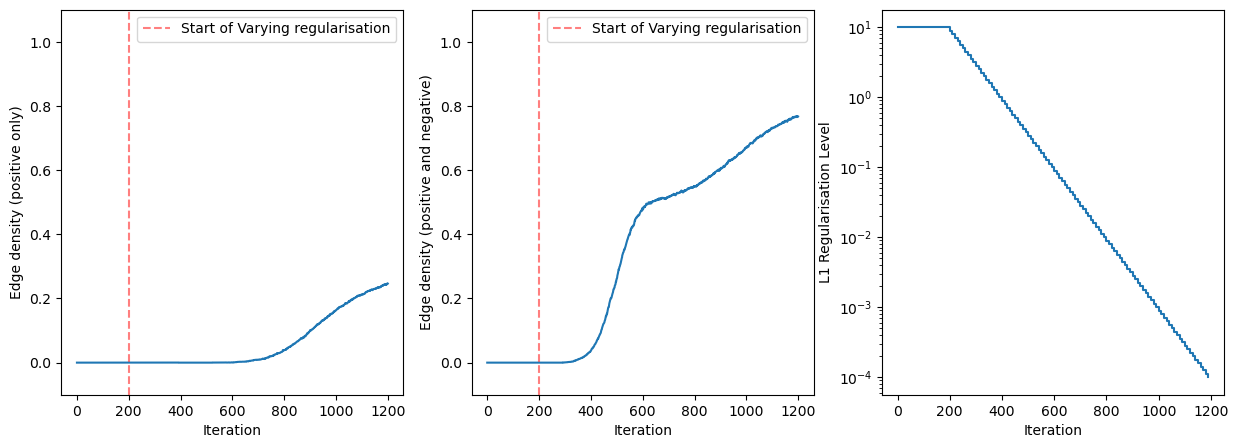

In [66]:
fig,ax = plt.subplots(ncols=3, figsize=(15,5))
q_theta_params = utils.convert_state_dicts(em_stored_vals["q_State_dicts"])
est_precs = torch.stack(q_theta_params["Precision"])
lower_diag = est_precs[:, lower_indices[0], lower_indices[1]]
print(est_precs.shape)
positive_rates = torch.mean((lower_diag>em_pos_quantiles[0]).float(),dim=-1)
abs_positive_rates = torch.mean((torch.abs(lower_diag)>em_abs_quantiles[0]).float(), dim=-1)
ax[0].plot(positive_rates)
ax[1].plot(abs_positive_rates)
ax[2].step(torch.cat((torch.zeros(1),change_points[:-1])), l1_regs, where="post")
ax[2].set_yscale("log")
em_index = torch.min(torch.nonzero(abs_positive_rates>0.5))
# Plot each change point as a vertical red line
for i in range(2):
    ax[i].set_xlabel("Iteration")
    ax[i].set_ylim(-0.1,1.1)
    ax[i].axvline(change_points[0], linestyle="--", color="red", alpha=0.5, label="Start of Varying regularisation")
    ax[i].legend()
ax[0].set_ylabel("Edge density (positive only)")
ax[1].set_ylabel("Edge density (positive and negative)")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("L1 Regularisation Level")
print(positive_rates[-1])
print(abs_positive_rates[-1])

In [ ]:
print(lower_diag.shape)
out = threshold_selector(torch.abs(lower_diag)[change_points-1], threshold=0.01, iters=3, steps=100, type="changes", angles=False)
print(out)
scores = torch.abs(lower_diag)
# Get positive rates for thresholds in shape (steps, nchange_points)
temp_positive_rates = torch.mean((scores > out).float(), dim=-1)

torch.Size([2200, 4465])
Current range: (1e-06, 0.1)
Reg levels at current range are: (tensor(0.0307), tensor(0.))
Current range: (8.111308488878421e-06, 9.111627150559798e-06)
Reg levels at current range are: (tensor(0.0103), tensor(0.0067))
Current range: (8.28464180813171e-06, 8.294379767903592e-06)
Reg levels at current range are: (tensor(0.0101), tensor(0.0099))
8.290251571452245e-06


### Plot Results

AUC: 0.910


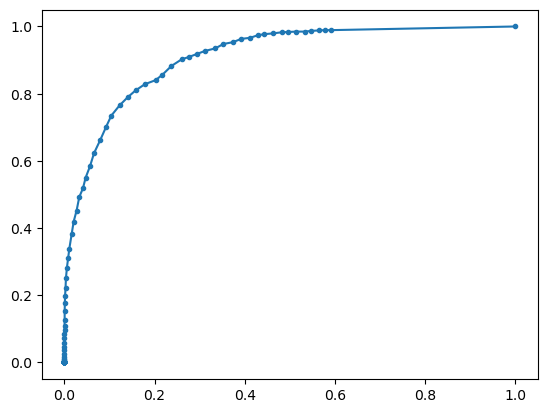

In [ ]:
est_precs = torch.stack([em_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.002
true_abs = (torch.abs(true_prec)>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()

AUC: 0.866


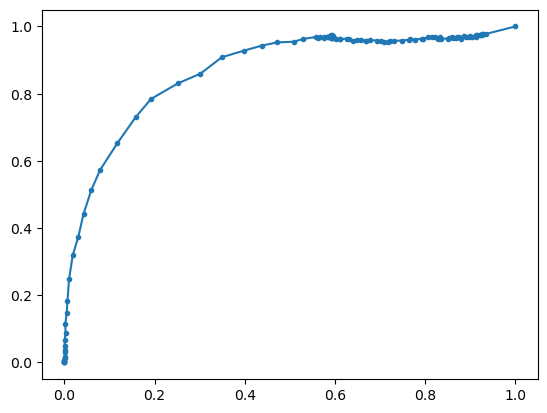

In [ ]:
est_precs = torch.stack([em_stored_vals["q_State_dicts"][index]["Precision"] for index in change_points-1])
true_prec = true_stored_vals["q_State_dicts"][true_index]["Precision"]

# Plot ROC curve from this

est_abs = torch.abs(est_precs)>0.002
true_abs = (torch.abs(torch.tensor(mle_runner.precision_))>0.002).float()
tpr, fpr = utils.data.tpr(true_abs, est_abs ), utils.data.fpr(true_abs, est_abs)
# Append 0 and 1 to begining and end of fpr and tpr
tpr = torch.cat((torch.zeros(1), tpr, torch.ones(1)))
fpr = torch.cat((torch.zeros(1), fpr, torch.ones(1)))
print(f"AUC: {utils.data.AUC(tpr, fpr):.3f}")
# plot line plot with dots at points
plt.plot(fpr, tpr, marker = "o", label="Variational", markersize=3)
plt.show()